In [ ]:
import torch


dataset_name = "okvqa"
ens_result_dict = torch.load(f"results/ensemble/{dataset_name}/exp_result.pth")


/tmp/ipykernel_3033587/1159463789.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ens_result_dict = torch.load(f"results/ensemble/{dataset_name}/exp_result.pth")


In [ ]:
import numpy as np

from data_generator.inference_loader import load_infer_prob_data
from ens_pruning.ens_methods import voting

# dataset_name = "mmmu" # okvqa
model_names = ens_result_dict["model_names"]
split_type = "validation" if dataset_name in ["mmmu", "okvqa"] else "test"
data = load_infer_prob_data(model_names, dataset_name, split_type)
label = data[:, -1]

model_probs = np.split(data[:, :-1], len(model_names), axis=1)
model_preds = []
for i in range(len(model_names)):
    print(np.mean(model_probs[i].argmax(1) == label))
    model_preds.append(model_probs[i].argmax(1))

model_preds = np.array(model_preds)
voting_ens = voting(model_preds.T, "plurality")

print("Plurality: ", np.mean(model_preds == label))

In [3]:
ens_result_dict.keys()

dict_keys(['val_acc', 'test_acc', 'state', 'model_names', 'logits', 'labels'])

In [4]:
ens_result_dict["model_names"]

['Qwen2.5-VL-7B-Instruct', 'InternVL2-8B', 'deepseek-vl2-small']

In [5]:
ens_result_dict["logits"].shape

(805, 36)

In [6]:
ens_result_dict["labels"][:100]

array([1., 2., 1., 3., 1., 0., 1., 0., 2., 0., 0., 0., 2., 1., 0., 2., 2.,
       3., 2., 1., 0., 1., 1., 0., 1., 0., 2., 0., 1., 0., 2., 4., 0., 4.,
       2., 0., 4., 1., 3., 1., 1., 0., 2., 0., 1., 3., 4., 2., 3., 4., 1.,
       1., 3., 0., 4., 3., 4., 3., 2., 0., 0., 0., 2., 2., 0., 0., 2., 1.,
       2., 1., 2., 1., 2., 1., 3., 1., 0., 1., 0., 1., 3., 0., 3., 3., 1.,
       1., 2., 2., 1., 2., 3., 3., 3., 0., 2., 3., 1., 2., 0., 0.])

In [7]:
ens_result_dict["test_acc"]

56.69117647058823

In [8]:
from scipy.stats import entropy

In [9]:
logits = ens_result_dict["logits"]
labels = ens_result_dict["labels"]
model_logits = logits[:, :-9]
ens_logits = logits[:, -9:]

In [10]:
model_logits.shape, ens_logits.shape

((805, 27), (805, 9))

In [11]:
H = entropy(ens_logits, base=2, axis=1)

In [12]:
import numpy as np
H[np.isnan(H)] = 0

In [13]:
import numpy as np
ens_preds = np.argmax(ens_logits, axis=1)

In [14]:
error_idx = ens_preds != labels

In [15]:
np.mean(H[error_idx]), np.mean(H[~error_idx])

(0.114885524, 0.056125633)

In [16]:
# model_count = len(model_names)
model_count = len(model_names)
space_size = 9  # 9
per_model_entropy = np.zeros(len(ens_logits))
for model_prob in np.split(model_logits, model_count, axis=1):
    per_model_entropy += entropy(model_prob, base=2, axis=1)

per_model_entropy /= model_count
per_model_entropy[np.isnan(per_model_entropy)] = 0

In [17]:
np.mean(per_model_entropy[error_idx]), np.mean(per_model_entropy[(~error_idx).astype(int)])

(0.9140744163897583, 0.8875148098908103)

In [18]:
epistomic_uncertainty = H - per_model_entropy

In [19]:
# model_count = len(model_names)
mean_ens = np.zeros((len(ens_logits), space_size))
for model_prob in np.split(model_logits, model_count, axis=1):
    mean_ens += model_prob
mean_ens /= model_count

In [20]:
np.mean(np.argmax(mean_ens, axis=1) == labels)

0.537888198757764

In [21]:
per_model_entropy[np.isnan(per_model_entropy)] = 0

In [22]:
H_ens = entropy(mean_ens, base=2, axis=1)
epistomic_uncertainty = H_ens - per_model_entropy

In [23]:
np.mean(epistomic_uncertainty[error_idx]), np.mean(epistomic_uncertainty[(~error_idx)])

(0.576970055643329, 0.5315918037295921)

In [24]:
a = np.sort(epistomic_uncertainty[:30])
for i in range(len(a)):
    print(a[i])


0.16259321618923406
0.17802986267221788
0.17814287618244218
0.22569627975049256
0.24193109939051172
0.24671542285171655
0.29865796834780944
0.31874420044825813
0.32968084370877015
0.34972713735156247
0.36586749583421874
0.4132429192447731
0.4860043159080141
0.49216838496563
0.49531831865657283
0.5183499312989852
0.5330180357191772
0.5365970851994891
0.5426757906570103
0.54392330077295
0.5580179875511126
0.5806938059720741
0.5826072775888119
0.5887149026081103
0.5969733899781474
0.6520179557924637
0.7542445867357118
0.7598922000348686
0.8412455672963881
1.47715768606939


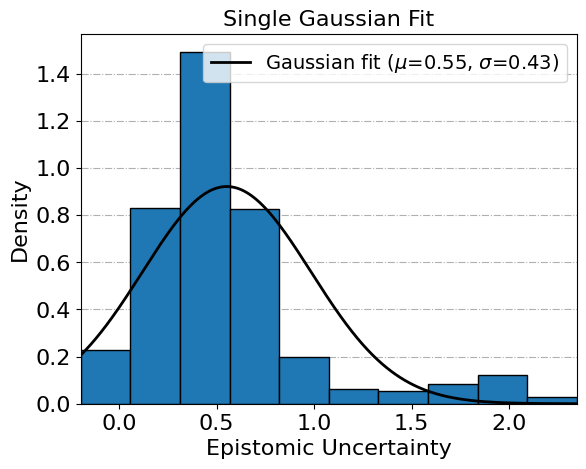

In [25]:
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
plt.rcParams.update({
        'font.size': 14,              # General font size
        'axes.titlesize': 16,         # Title font size
        'axes.labelsize': 16,         # Axis label font size
        'xtick.labelsize': 16,        # X-axis tick font size
        'ytick.labelsize': 16,        # Y-axis tick font size
        'legend.fontsize': 14         # Legend font size
    })


colormap = plt.cm.RdBu
colors = colormap(np.linspace(0.2, 1, 5))

fig, ax = plt.subplots()

# Example data
# epistomic_uncertainty = np.random.randn(100)

max_val = epistomic_uncertainty.max()
min_val = epistomic_uncertainty.min()
xx = np.linspace(min_val, max_val, 1000)

# Plot histogram
ax.hist(epistomic_uncertainty, bins=10, edgecolor='black', color="tab:blue", density=True, stacked=True, zorder=2)

# Fit a Gaussian (normal) distribution
mu, sigma = stats.norm.fit(epistomic_uncertainty)  # Maximum Likelihood Estimate
pdf = stats.norm.pdf(xx, mu, sigma)  # Evaluate PDF

# Plot the fitted Gaussian curve
ax.plot(xx, pdf, color="k", lw=2, label=f"Gaussian fit ($\mu$={mu:.2f}, $\sigma$={sigma:.2f})", zorder=2)

ax.set_xlabel("Epistomic Uncertainty")
ax.set_ylabel("Density")
ax.set_title("Single Gaussian Fit")
ax.set_xlim(min_val, max_val)
ax.grid(which='major', axis='y', linestyle='-.', zorder=0)
ax.legend()
# plt.savefig(f"results/figures/single_gaussian_okvqa.png", dpi=200, bbox_inches="tight")
plt.show()


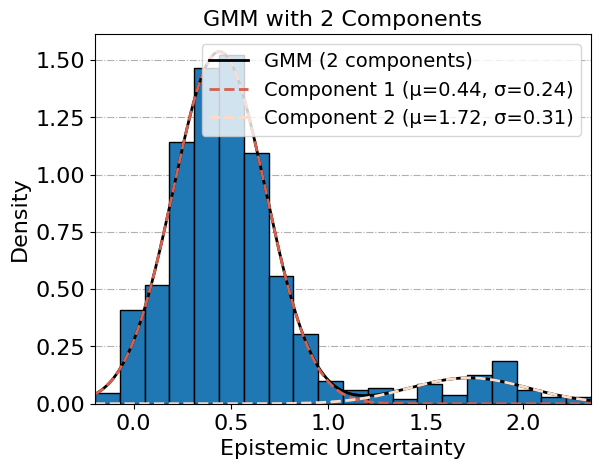

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# Example: your variable name
# epistomic_uncertainty = np.array(...)

# Step 1: standardize or log-transform if highly skewed
x = np.array(epistomic_uncertainty).reshape(-1, 1)
x_scaled = StandardScaler().fit_transform(x)

# Step 2: fit a more regularized GMM
gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    reg_covar=1e-2,      # prevents singular covariances
    random_state=0,
    init_params='kmeans' # better initialization
)
gmm.fit(x_scaled)

# Step 3: compute density
xx = np.linspace(x_scaled.min(), x_scaled.max(), 1000).reshape(-1, 1)
logprob = gmm.score_samples(xx)
pdf_scaled = np.exp(logprob)

# Convert grid back to original space
xx_orig = xx * np.std(epistomic_uncertainty) + np.mean(epistomic_uncertainty)

# Histogram
fig, ax = plt.subplots()
ax.hist(epistomic_uncertainty, bins=20, density=True, alpha=1,
        color='tab:blue', edgecolor='black', zorder=2)

# Step 4: plot mixture and components
ax.plot(xx_orig, pdf_scaled / np.std(epistomic_uncertainty),
        color='k', lw=2, label='GMM (2 components)', zorder=2)

# Individual components
means = gmm.means_.flatten() * np.std(epistomic_uncertainty) + np.mean(epistomic_uncertainty)
covars = gmm.covariances_.flatten() * (np.std(epistomic_uncertainty)**2)
weights = gmm.weights_

for i, (m, c, w) in enumerate(zip(means, covars, weights)):
    comp_pdf = w * (1/np.sqrt(2*np.pi*c)) * np.exp(-0.5*((xx_orig.flatten()-m)**2)/c)
    ax.plot(xx_orig, comp_pdf, '--', lw=2, color=colors[i],
            label=f'Component {i+1} (μ={m:.2f}, σ={np.sqrt(c):.2f})', zorder=2)

ax.set_xlabel("Epistemic Uncertainty")
ax.set_ylabel("Density")
ax.set_title("GMM with 2 Components")
ax.legend(loc="upper right")
ax.grid(which='major', axis='y', linestyle='-.', zorder=0)
ax.set_xlim(epistomic_uncertainty.min(), epistomic_uncertainty.max())
# plt.savefig(f"results/figures/gmm_okvqa.png", dpi=200, bbox_inches="tight")
plt.show()


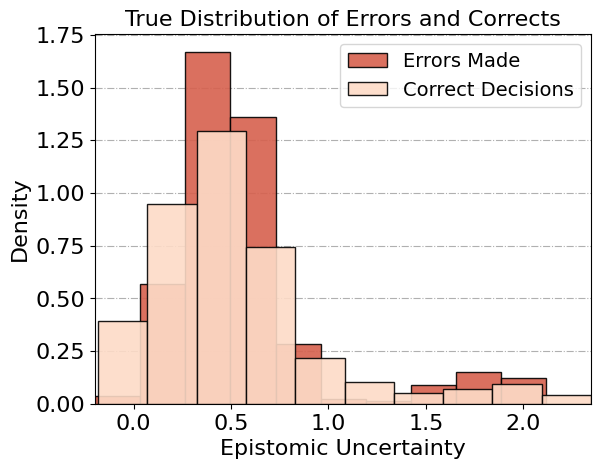

In [27]:
import matplotlib.pyplot as plt
from scipy import stats

fig, ax = plt.subplots()


max_val = epistomic_uncertainty.max()
min_val = epistomic_uncertainty.min()
xx = np.linspace(min_val, max_val, 1000)
ax.hist(epistomic_uncertainty[error_idx], bins=10, alpha=0.9, edgecolor='black', color=colors[0], label=f"Errors Made", density=True, stacked=True, zorder=3)
kde = stats.gaussian_kde(epistomic_uncertainty[error_idx])
# ax.plot(xx, kde(xx), color='k', lw=2)

idx_rev = (~error_idx)
ax.hist(epistomic_uncertainty[idx_rev], bins=10, alpha=0.9, edgecolor='black', color=colors[1], label=f"Correct Decisions", density=True, stacked=True, zorder=3)
kde = stats.gaussian_kde(epistomic_uncertainty[idx_rev])
# ax.plot(xx, kde(xx), color=colors[-1], lw=2)


ax.set_xlabel("Epistomic Uncertainty")
ax.set_ylabel("Density")
ax.set_title(f"True Distribution of Errors and Corrects")

ax.set_xlim(min_val, max_val)
ax.grid(which='major', axis='y', linestyle='-.', zorder=0)
# plt.savefig(f"results/figures/true_dist_okvqa.png", dpi=200, bbox_inches="tight")
ax.legend()

In [28]:
import numpy as np
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

def adaptive_entropy_threshold(entropies, alpha=10.0):
    entropies = np.array(entropies).reshape(-1, 1)

    # --- single Gaussian ---
    mu, sigma = np.mean(entropies), np.std(entropies)
    logL1 = np.sum(norm.logpdf(entropies, mu, sigma))

    # --- two-component GMM ---
    gmm = GaussianMixture(n_components=2, covariance_type='full',
                          reg_covar=1e-3,      # prevents singular covariances
                          random_state=0)
    gmm.fit(entropies)
    logL2 = gmm.score(entropies) * len(entropies)

    # --- model selection ---
    if (logL2 - logL1) > alpha:
        print("GMM with 2 components selected")
        labels = gmm.predict(entropies)
        group0 = entropies[labels == 0]
        group1 = entropies[labels == 1]
        tau = min(max(group0), max(group1))  # boundary between clusters
    else:
        print("Single Gaussian selected")
        tau = mu + 2 * sigma  # conservative high-entropy cutoff

    return tau



In [29]:
tau = adaptive_entropy_threshold(epistomic_uncertainty, alpha=10.0)[0]
print("tau", tau)

GMM with 2 components selected
tau 1.132673835828089


In [33]:
ens_logit_copy = ens_logits.copy()
idx = epistomic_uncertainty < 1.5
print(idx.sum() / len(idx), np.mean(labels[idx] == ens_logit_copy[idx].argmax(1)))

0.9341614906832298 0.5704787234042553


In [34]:
ens_logit_copy = ens_logits.copy()
idx = epistomic_uncertainty > 1.5
ens_logit_copy[idx] = mean_ens[idx]
print(np.mean(labels == ens_logit_copy.argmax(1)))

0.5527950310559007


In [32]:
ens_logit_copy = ens_logits.copy()
idx = H_ens > tau
ens_logit_copy[idx, ens_logits[idx].argmax(1)] = 0
print(np.mean(labels == ens_logit_copy.argmax(1)))

0.33540372670807456


In [141]:
before_acc = np.mean(labels == ens_logits.argmax(1))
after_acc = np.mean(labels == ens_logit_copy.argmax(1))
print(f"Befor acc: {before_acc}, After acc: {after_acc}")

Befor acc: 0.8445414847161572, After acc: 0.2366812227074236
